# Lab 6

### Group Members

| Names | ID |
| --- | --- |
| Arwa Alkhathlan | 2250030009 |
| Noor Albuainain | 2250030050 |
| Zainab Alharbi | 2250030246 |
| Joud Albeijan | 2250030261 |
| Sheehana Alghamdi | 2250030084 |
| Reem Alshehab | 2250030257 |

In [1]:
# To ignore warnings
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from ydata_profiling import ProfileReport
import sweetviz as sv

## 1. Load the dataset into a DataFrame

In [2]:
df_EC = pd.read_csv('Ecommerce Customers.csv')

# EDA

## 2. Explore the data (head, info, describe)

### head

In [3]:
df_EC.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


### info

In [4]:
df_EC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


### describe

In [5]:
df_EC.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [6]:
df_EC.describe(include='object').T

,count,unique,top,freq
Email,500,500,mstephenson@fernandez.com,1
Address,500,500,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",1
Avatar,500,138,Teal,7


### Shape

In [7]:
df_EC.shape

(500, 8)

### duplicated

In [8]:
df_EC.duplicated().sum()

np.int64(0)

In [9]:
df_EC[df_EC.duplicated()]

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent


### null

In [10]:
df_EC.isnull().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

### Outliers?

In [11]:
report = sv.analyze(df_EC)
report.show_html('report.html')

                                             |          | [  0%]   00:00 -> (? left)

Report report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


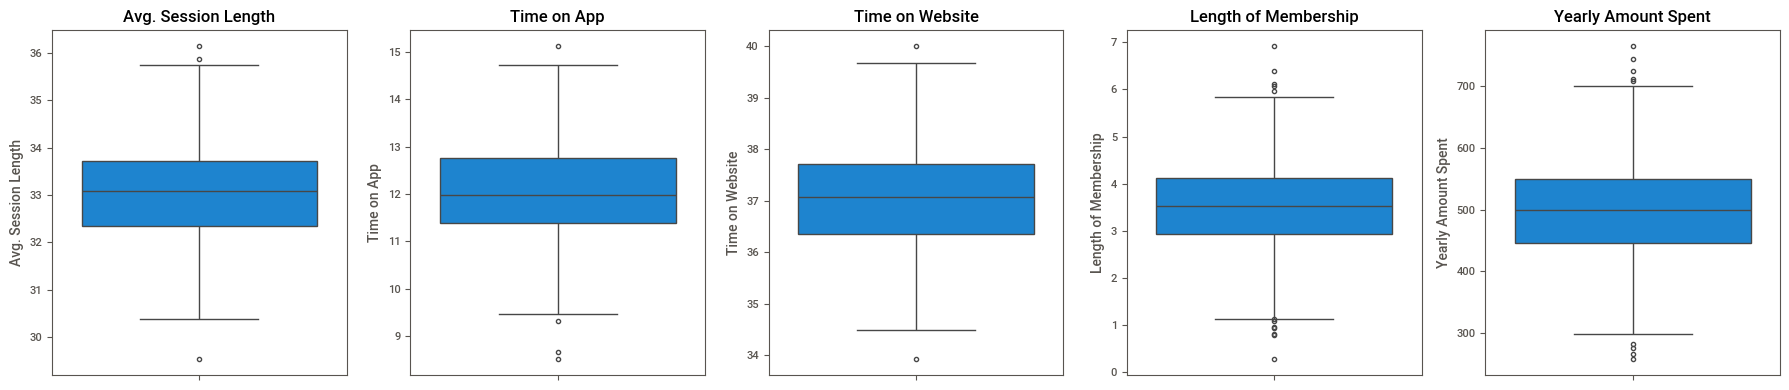

In [12]:
num_cols = df_EC.select_dtypes(include='number').columns

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df_EC[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [13]:
def iqr_outliers(df, cols):
    rows = []
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (df[col] < lower) | (df[col] > upper)
        rows.append({
            'Feature': col,
            'Q1': q1, 'Q3': q3, 'IQR': iqr,
            'Lower Bound': lower, 'Upper Bound': upper,
            'Outlier Count': mask.sum(),
            'Outlier %': round(mask.mean() * 100, 2)
        })
    return pd.DataFrame(rows).set_index('Feature')

iqr_summary = iqr_outliers(df_EC, num_cols)
iqr_summary

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
Feature,,,,,,,
Avg. Session Length,32.341822,33.711985,1.370163,30.286577,35.767230,3,0.6
Time on App,11.388153,12.753850,1.365696,9.339609,14.802394,4,0.8
Time on Website,36.349257,37.716432,1.367175,34.298495,39.767195,2,0.4
Length of Membership,2.930450,4.126502,1.196052,1.136371,5.920580,12,2.4
Yearly Amount Spent,445.038277,549.313828,104.275551,288.624951,705.727153,9,1.8


### Visulaiziton

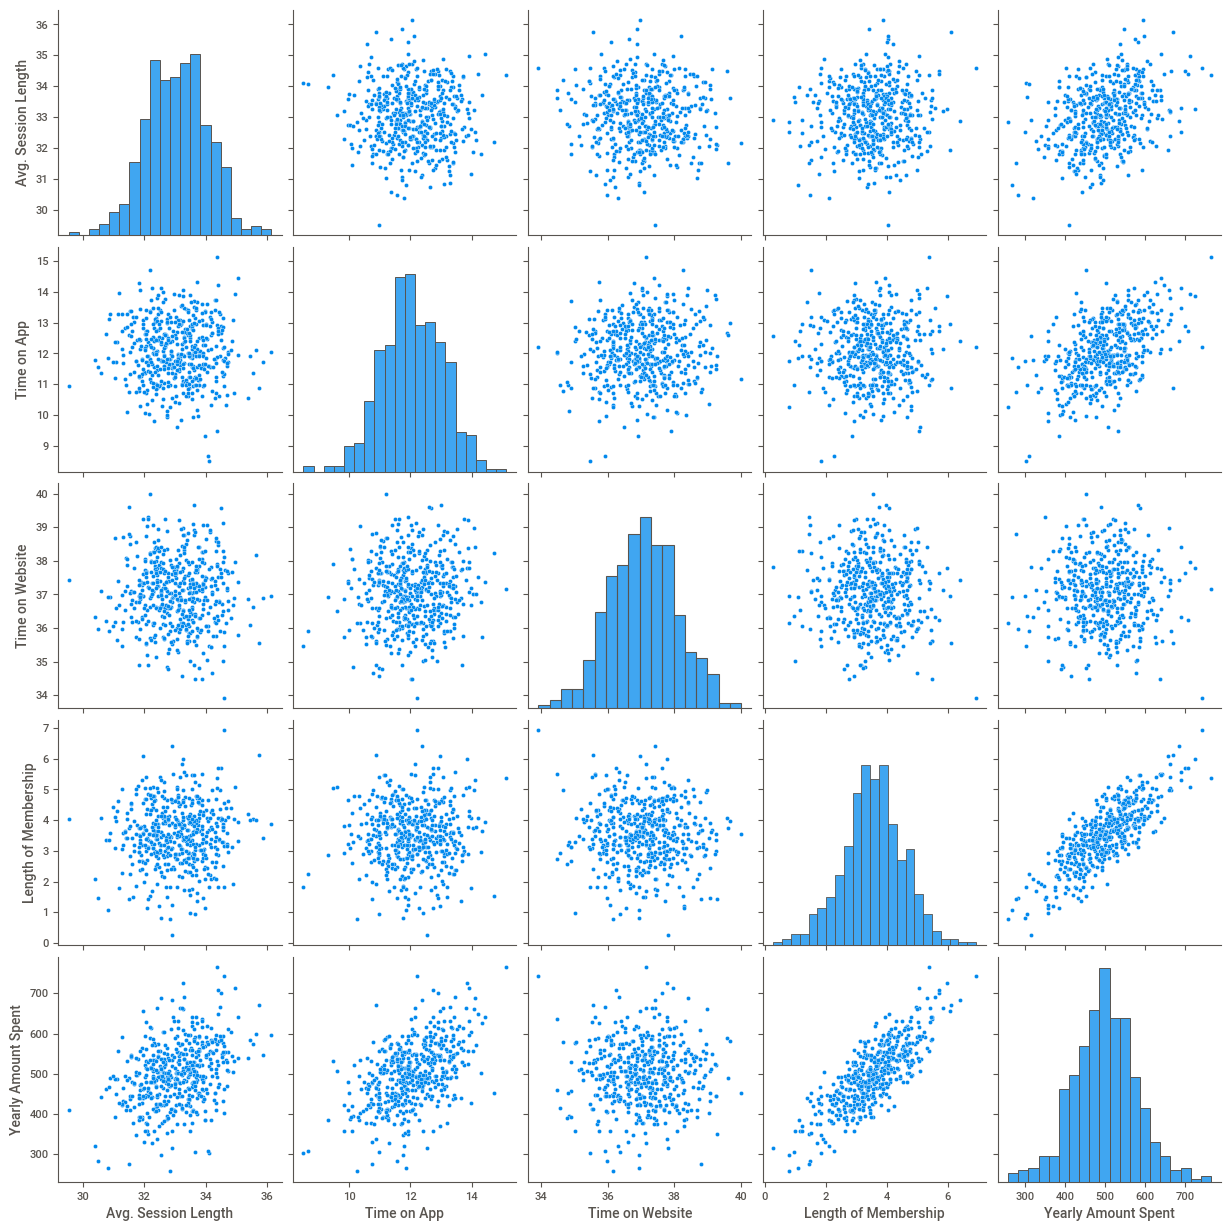

In [14]:
sns.pairplot(df_EC)

<Axes: xlabel='Yearly Amount Spent', ylabel='Count'>

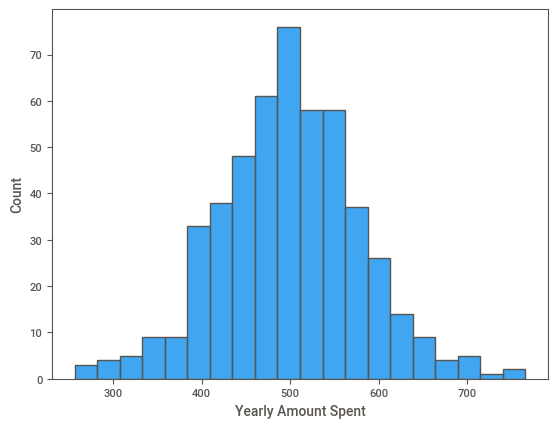

In [15]:
sns.histplot(df_EC['Yearly Amount Spent'])

<Axes: >

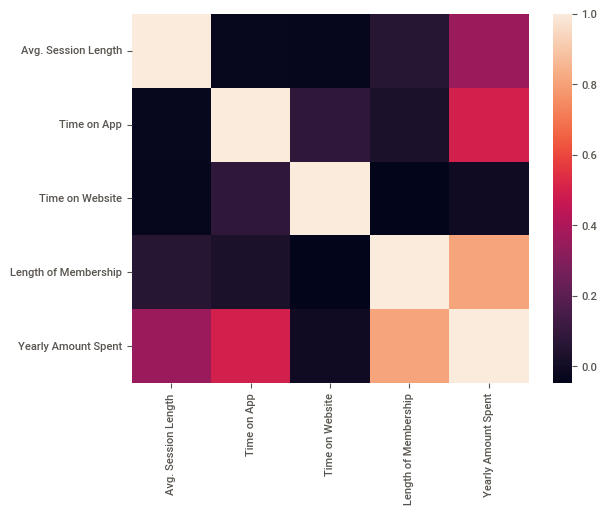

In [16]:
sns.heatmap(df_EC.select_dtypes(include='number').corr())

## 3. Perform basic data cleaning if needed

since the IQR outlier showed a tiny bit of outliers most of them are less then 1%, 
i think they will not affect the model as much really, but just in case i looked into the 
two coulmns that had more then 1% outliers and i made df_clean 
and i will compare the original df_EC with df_clean 

In [17]:
cols = ['Length of Membership', 'Yearly Amount Spent']
q1, q3 = df_EC[cols].quantile(0.25), df_EC[cols].quantile(0.75)
iqr = q3 - q1
mask = ~((df_EC[cols] < q1 - 1.5*iqr) | (df_EC[cols] > q3 + 1.5*iqr)).any(axis=1)

df_clean = df_EC[mask]
print(len(df_EC), len(df_clean))

500 483


## 4. Apply feature engineering (if applicable)

no need 

# this is for df_EC which has outliers

## 5. Prepare the data for modeling

### X and y arrays

In [18]:
X = df_EC[['Avg. Session Length','Time on App', 'Time on Website','Length of Membership']]
y = df_EC['Yearly Amount Spent']

### Train Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

## 6. Train a model (use the same model used in the lab)

In [20]:
lm = LinearRegression()
lm.fit(X_train,y_train)

LinearRegression()

## 7. Evaluate the model performance

In [21]:
print(lm.intercept_)

-1045.1152168245749


### Predictions from Model

In [22]:
predictions = lm.predict(X_test)

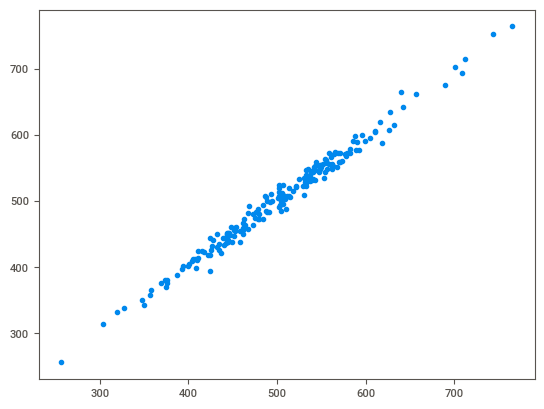

In [23]:
plt.scatter(y_test,predictions)

### Residual Histogram

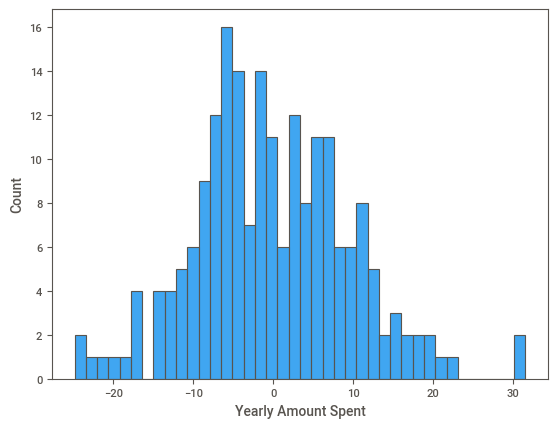

In [24]:
sns.histplot((y_test-predictions),bins=40);

### Regression Evaluation Metrics

In [25]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 7.74267128583873
MSE: 93.83297800820075
RMSE: 9.68674238370159


# this is for df_clean which has no outliers

## 5. Prepare the data for modeling

### X and y arrays

In [26]:
X = df_clean[['Avg. Session Length','Time on App', 'Time on Website','Length of Membership']]
y = df_clean['Yearly Amount Spent']

### Train Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

## 6. Train a model (use the same model used in the lab)

In [28]:
lm = LinearRegression()
lm.fit(X_train,y_train)

LinearRegression()

## 7. Evaluate the model performance

In [29]:
print(lm.intercept_)

-1021.1136327185666


In [30]:
coeff_df = pd.DataFrame(lm.coef_,X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Session Length,25.392249
Time on App,38.354591
Time on Website,0.046250
Length of Membership,61.458660


### Predictions from Model

In [31]:
predictions = lm.predict(X_test)

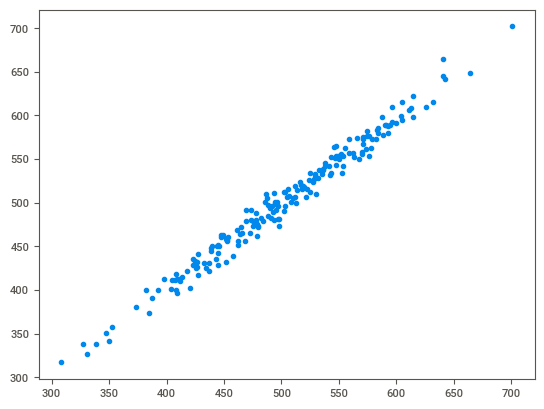

In [32]:
plt.scatter(y_test,predictions)

### Residual Histogram

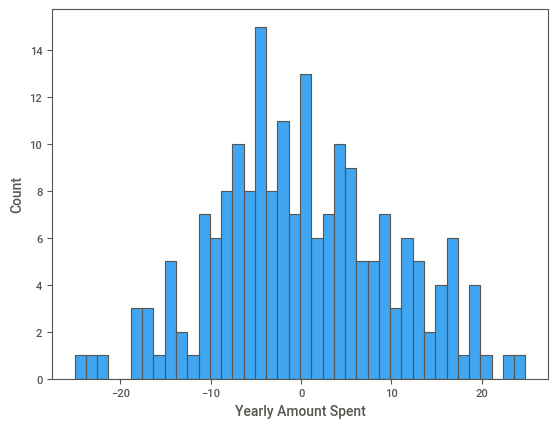

In [33]:
sns.histplot((y_test-predictions),bins=40);

### Regression Evaluation Metrics

In [34]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 7.84340031096673
MSE: 94.77942233524055
RMSE: 9.735472373503022


# conclusion

**Model 1** is better.

All three metrics (MAE, MSE, and RMSE) measure prediction error, so lower values indicate higher accuracy. Model 1 achieves lower error across all metrics:

| Metric | Model 1 | Model 2 | Difference (Model 1 Advantage) |
| --- | --- | --- | --- |
| **MAE** | **7.7427** | 7.8434 | ~1.28% lower error |
| **MSE** | **93.8330** | 94.7794 | ~1.00% lower error |
| **RMSE** | **9.6867** | 9.7355 | ~0.50% lower error |

does that weirdly means with outliers it's better? 
no i think because the outliers are needed since they do represnt real 
actual behavior of top spenders, rather than bad data.
when we removed the ouliers it reduced prediction accuracy. espically because 
the outlier percent was less then 5% even it was barley anything so removing it made the
model worst